In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import math

N_PEERS = 300
N_ITERS = 5
T_END = 300

In [6]:
def read_data(target: str):
    data = []
    for i in range(N_ITERS):
        with open(f'../scale/{target}/{N_PEERS}/r_{i}.txt', 'r') as f:
            time_init = 0
            time_points = []
            reachabilities = []
            
            for line in f:
                parts = line.strip().split()
                if parts[1] == 'N/A':
                    continue

                time = int(parts[0])
                if time_init == 0:
                    time_init = time
                execution_time = (time - time_init) / 1000
                reachability = float(parts[1])
                    
                # time interpolation
                if len(time_points) > 0:
                    time_points.append(execution_time)
                    reachabilities.append(reachabilities[-1])
                
                time_points.append(execution_time)
                reachabilities.append(reachability * 100)
            if time_points[-1] < T_END:
                time_points.append(float(T_END))
                reachabilities.append(reachabilities[-1])
            
            data.append((time_points, reachabilities))
    return data

In [7]:
import matplotlib.pyplot as plt

def plot_four(data: list[list[tuple[list[float], list[float]]]], titles: list[str]):
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 6,
        "axes.titlesize": 6,
        "axes.labelsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "figure.titlesize": 6,
    })
    
    fig, axes = plt.subplots(1, 4, figsize=(8, 1.5), sharey=True)

    for i, (ax, lines) in enumerate(zip(axes, data)):
        for x, y in lines:
            ax.plot(x, y, color='black', alpha=0.3, linewidth=1)

        if i == 0:
            ax.set_ylabel('Discovery (%)', labelpad=1)

        ax.set_xlabel(titles[i], labelpad=1)
        #ax.xaxis.set_major_locator(ticker.MultipleLocator(150))
        ax.grid(True)

        if i != 0:
            ax.tick_params(labelleft=False)

    fig.tight_layout(pad=0)
    plt.savefig(f'_scale_trend.jpg', dpi=600, bbox_inches='tight', pad_inches=0)

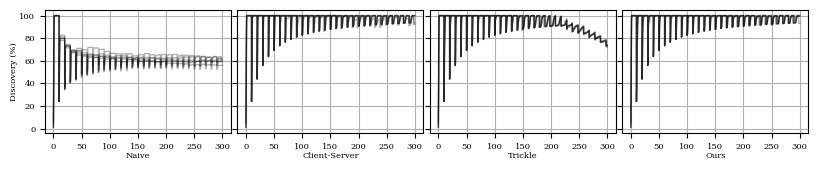

In [8]:
x = [i * 0.1 for i in range(63)]
data = [read_data(target) for target in ['dev-eval-naive', 'client-server', 'dev-eval-trickle', 'dev-v2']]

plot_four(data, titles=['Naive', 'Client-Server', 'Trickle', 'Ours'])